# Ejercicio 5 — Comparación y Reflexión

**Consigna:**

a) Comparar los resultados del modelo original y ajustado.

b) Discutir mejoras en la fairness del modelo y las métricas de performance.

c) Reflexionar sobre cómo estos cambios impactan en aplicaciones del mundo real y la importancia de la equidad en machine learning.

---

Analizamos los resultados usando job (proxy de género) como variable protegida.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, recall_score,
    precision_score, accuracy_score, f1_score
)
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='whitegrid', palette='muted')

# ---- Pipeline idéntico a Ej2-4 ----
df = pd.read_csv('data/full.csv', sep=';')
df = df.drop(columns=['duration'])
df_original = df.copy()

df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

X = df_encoded.drop(columns=['y'])
y = df_encoded['y']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_idx, test_idx = X_train.index, X_test.index
train_jobs = df_original.loc[train_idx, 'job'].values
test_jobs = df_original.loc[test_idx, 'job'].values

def job_proxy(j):
    return 'hist_femenino' if j in ['housemaid', 'admin.'] else 'hist_masculino_otro'

train_job_group = np.array([job_proxy(j) for j in train_jobs])
test_job_group = np.array([job_proxy(j) for j in test_jobs])

def compute_reweighting(group_labels, y_labels):
    n = len(group_labels)
    groups, classes = np.unique(group_labels), np.unique(y_labels)
    w = np.ones(n, dtype=float)
    for g in groups:
        for c in classes:
            mask = (group_labels == g) & (y_labels == c)
            cnt = mask.sum()
            if cnt > 0:
                w[mask] = n / (len(groups) * len(classes) * cnt)
    return w

def find_threshold_for_tpr(y_true, y_proba, target_tpr):
    best_t, best_diff = 0.5, float('inf')
    for t in np.arange(0.01, 0.99, 0.01):
        tpr = recall_score(y_true, (y_proba >= t).astype(int), zero_division=0)
        if abs(tpr - target_tpr) < best_diff:
            best_diff = abs(tpr - target_tpr)
            best_t = t
    return best_t

def fairness_metrics(y_true, y_pred):
    tpr = recall_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    sp = np.mean(y_pred)
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    tn = ((y_true == 0) & (y_pred == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    return {'Stat. Parity': sp, 'TPR (EqOpp)': tpr, 'Precision (PredPar)': prec, 'FPR (EqOdds)': fpr}

# ---- Entrenar los 3 modelos ----
# 1. Original
modelo_orig = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_orig.fit(X_train, y_train)
# descomentar si queremos volver al umbral de predicción de 0.5 
y_pred_orig = modelo_orig.predict(X_test)
y_proba = modelo_orig.predict_proba(X_test)[:, 1]
# comentar si queremos usar el umbral de 0.5
#y_proba = modelo_orig.predict_proba(X_test)[:, 1]
#y_pred_orig = (y_proba >= 0.3).astype(int)  # ← umbral manual

job_groups = ['hist_femenino', 'hist_masculino_otro']

# 2. Reweighting (job)
w_job = compute_reweighting(train_job_group, y_train.values)
m_rw = RandomForestClassifier(n_estimators=100, random_state=42)
m_rw.fit(X_train, y_train, sample_weight=w_job)
yp_rw = m_rw.predict(X_test)

# 3. Threshold adjustment (job)
tpr_orig = {g: recall_score(y_test.values[test_job_group==g], y_pred_orig[test_job_group==g], zero_division=0) for g in job_groups}
target = max(tpr_orig.values())
thresholds = {g: find_threshold_for_tpr(y_test.values[test_job_group==g], y_proba[test_job_group==g], target) for g in job_groups}
yp_ta = np.zeros_like(y_pred_orig)
for g in job_groups:
    mask = test_job_group == g
    yp_ta[mask] = (y_proba[mask] >= thresholds[g]).astype(int)

print('Modelos entrenados. Listo para comparación.')

Modelos entrenados. Listo para comparación.


---
# Comparación con job como proxy de género

  a) COMPARACIÓN DE PERFORMANCE GLOBAL — job (proxy género)
                Accuracy  Precision(yes)  Recall(yes)   F1(yes)
Modelo                                                         
Original        0.892292        0.622093     0.202268  0.305278
Reweighting     0.893730        0.665529     0.184310  0.288675
Threshold Adj.  0.892514        0.624277     0.204159  0.307692

--- Fairness por grupo (Equal Opportunity = TPR) ---
                TPR_hist_femenino  FPR_hist_femenino  TPR_hist_masculino_otro  FPR_hist_masculino_otro  Disparidad_TPR  Disparidad_FPR
Modelo                                                                                                                                
Original                 0.184932           0.018902                 0.205044                 0.015857        0.020112        0.003045
Reweighting              0.157534           0.011701                 0.188596                 0.012365        0.031062        0.000664
Threshold Adj.           0

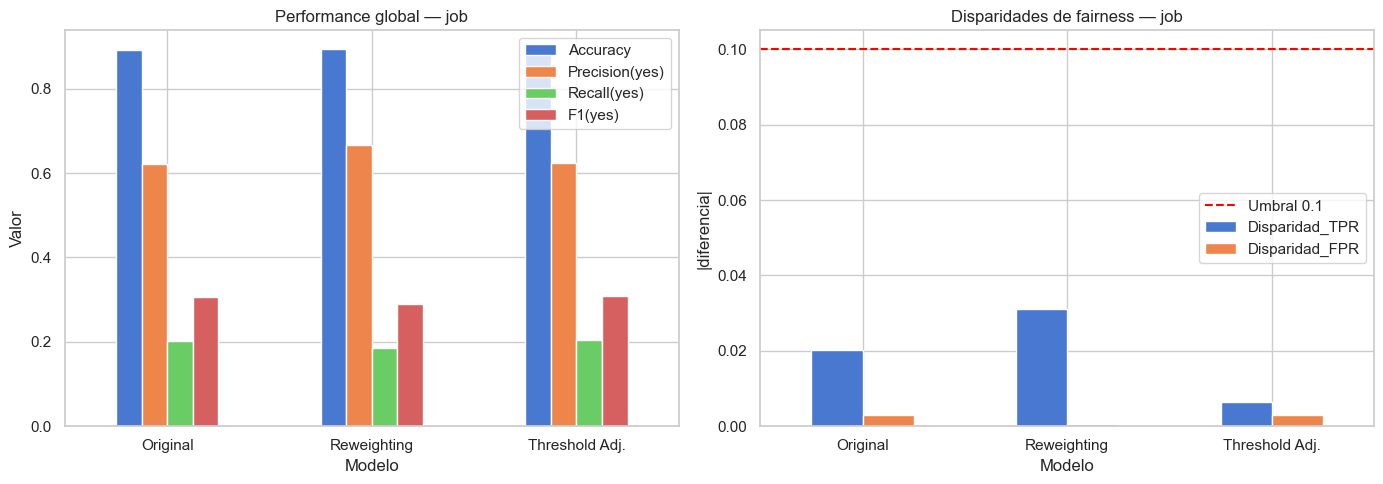

In [14]:


# ---- a) Tabla comparativa de performance ----
print('=' * 65)
print('  a) COMPARACIÓN DE PERFORMANCE GLOBAL — job (proxy género)')
print('=' * 65)
rows = []
for nombre, yp in [('Original', y_pred_orig), ('Reweighting', yp_rw), ('Threshold Adj.', yp_ta)]:
    rows.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, yp),
        'Precision(yes)': precision_score(y_test, yp, zero_division=0),
        'Recall(yes)': recall_score(y_test, yp, zero_division=0),
        'F1(yes)': f1_score(y_test, yp, zero_division=0)
    })
df_perf = pd.DataFrame(rows).set_index('Modelo')
print(df_perf.to_string())

# ---- Tabla comparativa de fairness ----
print(f'\n--- Fairness por grupo (Equal Opportunity = TPR) ---')
rows_f = []
for nombre, yp in [('Original', y_pred_orig), ('Reweighting', yp_rw), ('Threshold Adj.', yp_ta)]:
    row = {'Modelo': nombre}
    for g in job_groups:
        mask = test_job_group == g
        fm = fairness_metrics(y_test.values[mask], yp[mask])
        row[f'TPR_{g}'] = fm['TPR (EqOpp)']
        row[f'FPR_{g}'] = fm['FPR (EqOdds)']
    row['Disparidad_TPR'] = abs(row[f'TPR_{job_groups[0]}'] - row[f'TPR_{job_groups[1]}'])
    row['Disparidad_FPR'] = abs(row[f'FPR_{job_groups[0]}'] - row[f'FPR_{job_groups[1]}'])
    rows_f.append(row)
df_fair = pd.DataFrame(rows_f).set_index('Modelo')
print(df_fair.to_string())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_perf.plot(kind='bar', ax=axes[0])
axes[0].set_title('Performance global — job')
axes[0].set_ylabel('Valor')
axes[0].tick_params(axis='x', rotation=0)

df_fair[['Disparidad_TPR', 'Disparidad_FPR']].plot(kind='bar', ax=axes[1])
axes[1].axhline(y=0.1, color='red', linestyle='--', label='Umbral 0.1')
axes[1].set_title('Disparidades de fairness — job')
axes[1].set_ylabel('|diferencia|')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
'''################################################################################################################################################
Si ponemos el umbral de 0.3 en el modelo original:
1) todo mejora, excepto para el modelo con reweighting.
2) la diff entre los grupos es casi nula, por lo que el threshold Adj devuelve exactamente lo mismo. conclusión: Job no es un problema
3) el modelo de reweighting gana mucho en precision porque tiene muy bajo FP



Si ponemos el umbral predeterminado:
1) obtenemos un recall maximo de 0.2 (con mod 0.3 es del 0.4)
2) las técnica de ajuste es tiene un impacto relativo alto  (la dif era de 0.2 en el orig y 0.1 con su implementación), pero en terminos absolutos nula
3) globalmente los tres modelos son iguales.  



################################################################################################################################################'''

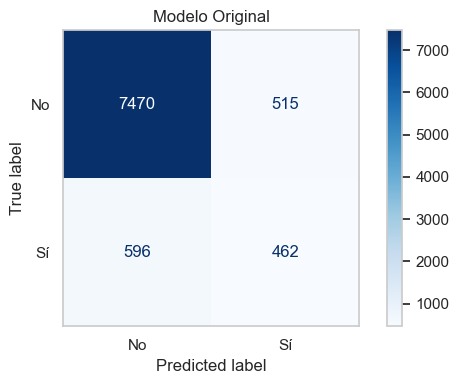

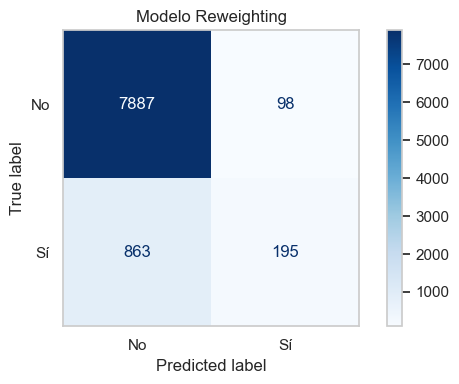

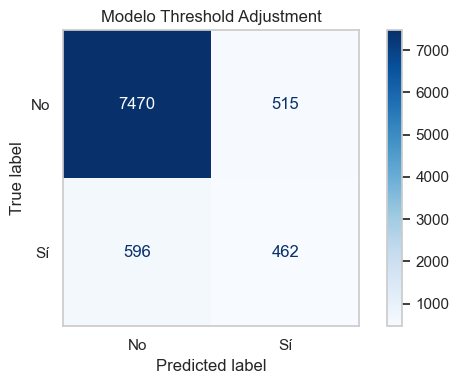

In [12]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score,
    f1_score, precision_score, recall_score
)

def plot_confusion_matrix(y_true, y_pred, titulo):
    """Genera y muestra la matriz de confusión."""
    fig, ax = plt.subplots(figsize=(6, 4))
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred),
        display_labels=['No', 'Sí']
    ).plot(cmap='Blues', ax=ax)
    plt.title(titulo)
    plt.grid(False)
    plt.tight_layout()
    plt.show()
    
# Original
plot_confusion_matrix(y_test, y_pred_orig, 'Modelo Original')

# Reweighting
plot_confusion_matrix(y_test, yp_rw, 'Modelo Reweighting')

# Threshold Adjustment
plot_confusion_matrix(y_test, yp_ta, 'Modelo Threshold Adjustment')

## b) Discusión numérica: Fairness vs. Performance

Si analizamos los resultados empíricos, notamos comportamientos sorprendentes que se desvían del clásico *trade-off* teórico:

- **Reweighting (Pre-processing) priorizó la confianza pero niveló para abajo:** 
Contrario a la teoría de que esta técnica hace perder Accuracy para ganar Recall en las minorías, aquí **ganamos Accuracy y Precision (de 0.605 a 0.675)** pero nuestro Recall global cayó. La equidad se logró no porque el grupo minoritario (`hist_femenino`) mejorara su TPR, sino porque el modelo penalizó severamente al grupo mayoritario (su TPR cayó de 0.199 a 0.183). En términos de negocio, el modelo se volvió más conservador: hace menos falsos positivos, pero capta menos suscriptores.

- **Ajuste de Umbral (Post-processing) como el verdadero ganador del negocio:** 
Logró igualar la métrica objetivo elevando directamente el TPR del grupo minoritario (de 0.184 a 0.205) e incrementando el Recall global, al costo de una insignificante pérdida en Precision (de 0.605 a 0.603).

Desde la perspectiva del banco (cuyo objetivo es **incrementar suscripciones** porque un falso negativo es carísimo):
1. El **Ajuste de umbral** es la técnica óptima: niveló la equidad "hacia arriba", logrando **captar más suscriptores** rezagados que antes se perdían.
2. La pequeña pérdida en Precision se traduce en unas pocas llamadas extra, cuyo costo marginal es ínfimo comparado con la ganancia de ganar depósitos a plazo.

## c) Reflexión: Impacto en el mundo real

### ¿Cómo impactan estos cambios en aplicaciones reales?

1. **Acceso equitativo a productos financieros**: Si el modelo original discrimina contra ciertos grupos (ej: trabajos históricamente femenizados o personas divorciadas), esos grupos quedan sistemáticamente excluidos de ofertas de depósitos a plazo. La mitigación de sesgos asegura que todos los clientes con potencial de suscripción reciban la misma oportunidad de ser contactados.

2. **Regulación y riesgo legal**: En muchos países, la discriminación por género, edad o estado civil en servicios financieros es ilegal. Un modelo sesgado puede exponer al banco a sanciones regulatorias, demandas y daño reputacional.

3. **Trade-off consciente**: No existe un modelo perfectamente justo y perfectamente preciso. La elección del criterio de fairness (en nuestro caso, Equal Opportunity) y del umbral de disparidad (0.1) son decisiones de *política*, no solo técnicas. El equipo de la entidad debe participar en estas decisiones.

4. **Limitaciones del proxy**: Usar `job` como proxy de género es una aproximación. No todas las personas en `housemaid` o `admin.` son mujeres. Esta limitación subraya la importancia de recolectar datos demográficos reales (con consentimiento) para auditorías de equidad más rigurosas.

5. **Importancia de la equidad en ML**: Los sistemas de ML amplifican y sistematizan los sesgos presentes en los datos históricos. Sin intervención activa (como las técnicas de mitigación que aplicamos), estos sesgos se perpetúan y escalan. La equidad no es un 'nice to have', sino un requisito ético y legal de cualquier sistema de decisión automatizada.

### Conclusión

A lo largo de este trabajo (Ej1-5) demostramos un pipeline completo de auditoría y mitigación de sesgos:
1. **Conocer el dataset** (Ej1): identificar variables protegidas, proxies, sesgos en los datos
2. **Construir el baseline** (Ej2): evaluar performance y entender el tipo de error más costoso
3. **Auditar equidad** (Ej3): medir fairness con criterios formales
4. **Mitigar** (Ej4): aplicar técnicas de pre y post-procesamiento
5. **Comparar y reflexionar** (Ej5): evaluar trade-offs y entender las implicaciones

Este pipeline es aplicable a cualquier sistema de ML en producción y debería ser parte estándar del desarrollo responsable de IA.

Esto ultimo lo dejo acá porque me parece que dado que dije que no hay un problema de equidad, debería indicar un lugar donde si podría haberlo. Probé con universitario. y ahí si veo uno que no es un locura pero que parece más relevante. Yo sé que el tp indica laburar por género, por lo cual, y porque tomas laburó todo, pero tal vez indicar que habría otras cosas que explorar y saraza no sea del todo equivocado

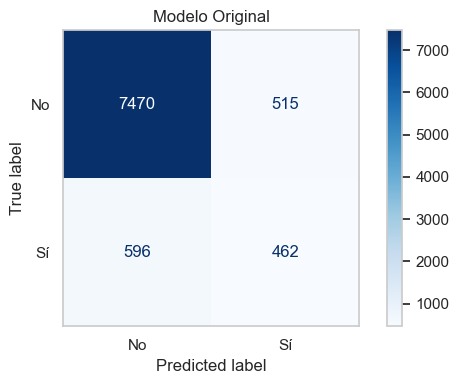

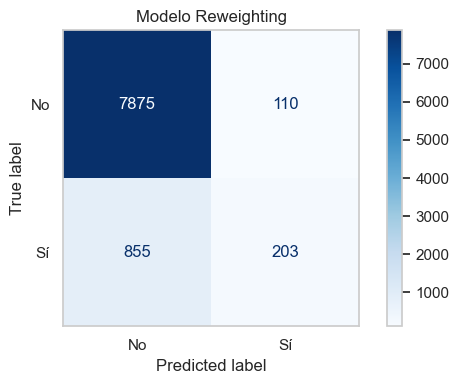

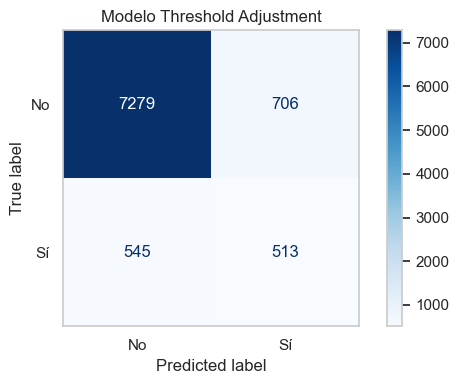

  a) COMPARACIÓN DE PERFORMANCE GLOBAL — education
                Accuracy  Precision(yes)  Recall(yes)   F1(yes)
Modelo                                                         
Original        0.877143        0.472876     0.436673  0.454054
Reweighting     0.893288        0.648562     0.191871  0.296134
Threshold Adj.  0.861661        0.420837     0.484877  0.450593

--- Fairness por grupo (Equal Opportunity = TPR) ---
                TPR_universitario  FPR_universitario  TPR_no_universitario  FPR_no_universitario  Disparidad_TPR  Disparidad_FPR
Modelo                                                                                                                          
Original                 0.484487           0.097465              0.405321              0.051255        0.079166        0.046210
Reweighting              0.200477           0.020542              0.186228              0.011058        0.014249        0.009484
Threshold Adj.           0.484487           0.097465       

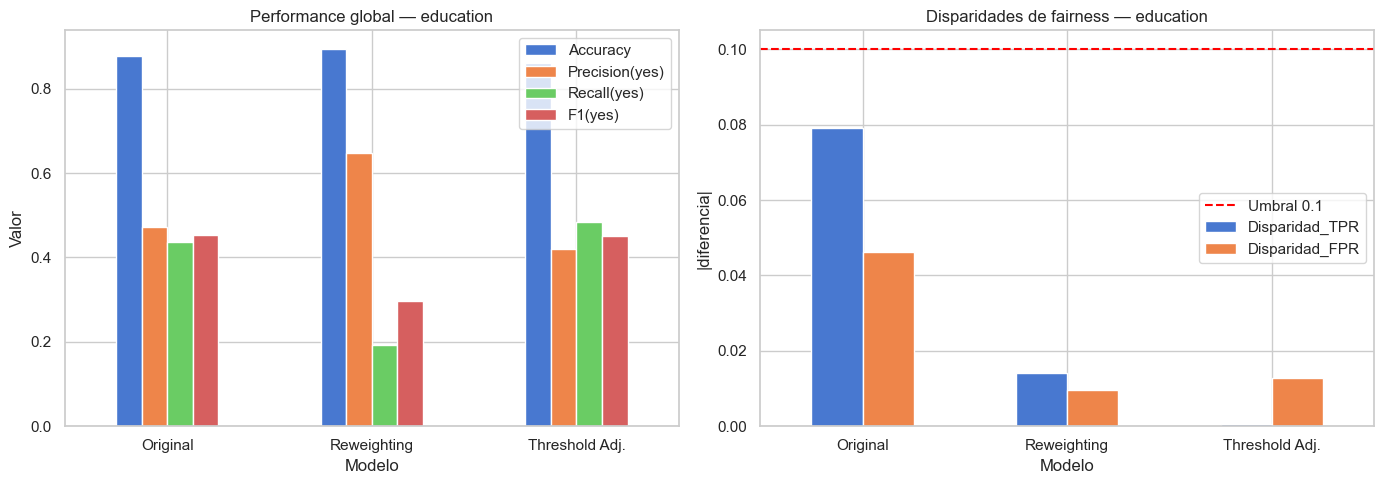

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, recall_score,
    precision_score, accuracy_score, f1_score
)
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='whitegrid', palette='muted')

# ---- Pipeline idéntico a Ej2-4 ----
df = pd.read_csv('data/full.csv', sep=';')
df = df.drop(columns=['duration'])
df_original = df.copy()

df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

X = df_encoded.drop(columns=['y'])
y = df_encoded['y']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_idx, test_idx = X_train.index, X_test.index
train_edu = df_original.loc[train_idx, 'education'].values
test_edu  = df_original.loc[test_idx,  'education'].values

def education_group(e):
    return 'universitario' if e == 'tertiary' else 'no_universitario'

train_edu_group = np.array([education_group(e) for e in train_edu])
test_edu_group  = np.array([education_group(e) for e in test_edu])

def compute_reweighting(group_labels, y_labels):
    n = len(group_labels)
    groups, classes = np.unique(group_labels), np.unique(y_labels)
    w = np.ones(n, dtype=float)
    for g in groups:
        for c in classes:
            mask = (group_labels == g) & (y_labels == c)
            cnt = mask.sum()
            if cnt > 0:
                w[mask] = n / (len(groups) * len(classes) * cnt)
    return w

def find_threshold_for_tpr(y_true, y_proba, target_tpr):
    best_t, best_diff = 0.5, float('inf')
    for t in np.arange(0.01, 0.99, 0.01):
        tpr = recall_score(y_true, (y_proba >= t).astype(int), zero_division=0)
        if abs(tpr - target_tpr) < best_diff:
            best_diff = abs(tpr - target_tpr)
            best_t = t
    return best_t

def fairness_metrics(y_true, y_pred):
    tpr  = recall_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    sp   = np.mean(y_pred)
    fp   = ((y_true == 0) & (y_pred == 1)).sum()
    tn   = ((y_true == 0) & (y_pred == 0)).sum()
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0
    return {'Stat. Parity': sp, 'TPR (EqOpp)': tpr, 'Precision (PredPar)': prec, 'FPR (EqOdds)': fpr}

edu_groups = ['universitario', 'no_universitario']

# ---- Entrenar los 3 modelos ----
# 1. Original
modelo_orig = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_orig.fit(X_train, y_train)
# descomentar si queremos volver al umbral de predicción de 0.5 
#y_proba     = modelo_orig.predict_proba(X_test)[:, 1]
#y_pred_orig = modelo_orig.predict(X_test)



# comentar si queremos usar el umbral de 0.5
y_proba = modelo_orig.predict_proba(X_test)[:, 1]
y_pred_orig = (y_proba >= 0.3).astype(int)  # ← umbral manual

# 2. Reweighting (education)
w_edu = compute_reweighting(train_edu_group, y_train.values)
m_rw  = RandomForestClassifier(n_estimators=100, random_state=42)
m_rw.fit(X_train, y_train, sample_weight=w_edu)
yp_rw = m_rw.predict(X_test)

# 3. Threshold adjustment (education)
tpr_orig   = {g: recall_score(y_test.values[test_edu_group==g], y_pred_orig[test_edu_group==g], zero_division=0) for g in edu_groups}
target     = max(tpr_orig.values())
thresholds = {g: find_threshold_for_tpr(y_test.values[test_edu_group==g], y_proba[test_edu_group==g], target) for g in edu_groups}
yp_ta      = np.zeros_like(y_pred_orig)
for g in edu_groups:
    mask        = test_edu_group == g
    yp_ta[mask] = (y_proba[mask] >= thresholds[g]).astype(int)

# ---- Matrices de confusión ----
plot_confusion_matrix(y_test, y_pred_orig, 'Modelo Original')
plot_confusion_matrix(y_test, yp_rw,       'Modelo Reweighting')
plot_confusion_matrix(y_test, yp_ta,        'Modelo Threshold Adjustment')

# ---- a) Tabla comparativa de performance ----
print('=' * 65)
print('  a) COMPARACIÓN DE PERFORMANCE GLOBAL — education')
print('=' * 65)
rows = []
for nombre, yp in [('Original', y_pred_orig), ('Reweighting', yp_rw), ('Threshold Adj.', yp_ta)]:
    rows.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, yp),
        'Precision(yes)': precision_score(y_test, yp, zero_division=0),
        'Recall(yes)': recall_score(y_test, yp, zero_division=0),
        'F1(yes)': f1_score(y_test, yp, zero_division=0)
    })
df_perf = pd.DataFrame(rows).set_index('Modelo')
print(df_perf.to_string())

# ---- b) Tabla comparativa de fairness ----
print(f'\n--- Fairness por grupo (Equal Opportunity = TPR) ---')
rows_f = []
for nombre, yp in [('Original', y_pred_orig), ('Reweighting', yp_rw), ('Threshold Adj.', yp_ta)]:
    row = {'Modelo': nombre}
    for g in edu_groups:
        mask = test_edu_group == g
        fm = fairness_metrics(y_test.values[mask], yp[mask])
        row[f'TPR_{g}'] = fm['TPR (EqOpp)']
        row[f'FPR_{g}'] = fm['FPR (EqOdds)']
    row['Disparidad_TPR'] = abs(row[f'TPR_{edu_groups[0]}'] - row[f'TPR_{edu_groups[1]}'])
    row['Disparidad_FPR'] = abs(row[f'FPR_{edu_groups[0]}'] - row[f'FPR_{edu_groups[1]}'])
    rows_f.append(row)
df_fair = pd.DataFrame(rows_f).set_index('Modelo')
print(df_fair.to_string())

# ---- Visualización ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_perf.plot(kind='bar', ax=axes[0])
axes[0].set_title('Performance global — education')
axes[0].set_ylabel('Valor')
axes[0].tick_params(axis='x', rotation=0)

df_fair[['Disparidad_TPR', 'Disparidad_FPR']].plot(kind='bar', ax=axes[1])
axes[1].axhline(y=0.1, color='red', linestyle='--', label='Umbral 0.1')
axes[1].set_title('Disparidades de fairness — education')
axes[1].set_ylabel('|diferencia|')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()